In [1]:
#Imports
import numpy as np
from kinematics_functions import *
from scipy.integrate import solve_ivp
from tqdm import tqdm



# Spesific problem parameters

# d values, consisten with following answer to question 1, not consistent with estimates we did for kinematics part of poject
d_1 = 0.34
d_3 = 0.40    # upper arm  (shoulder → elbow)
d_5 = 0.40    # forearm    (elbow → wrist)
d_7 = 0.126   # flange/tool (wrist → flange)

# DH_table
def DH(q):
    return np.array([
        # d,    theta,  a,  alpha
        [d_1,   q[0],   0,  np.pi/2 ],
        [0,     q[1],   0, -np.pi/2 ],
        [d_3,   q[2],   0, -np.pi/2 ],
        [0,     q[3],   0,  np.pi/2 ],
        [d_5,   q[4],   0,  np.pi/2 ],
        [0,     q[5],   0, -np.pi/2 ],
        [d_7,   q[6],   0,  0       ],
    ])


3.141592653589793


# Question 1 - Approximate Link Inertias 

## Method

Each of the 7 links is approximated as a **single solid cylinder** sized to the
arm's outer envelope. Lengths come from the published iiwa kinematic offsets
(0.34 / 0.40 / 0.40 / 0.126 m for the limb segments; the shoulder, elbow and
wrist joint-pairs are co-located, so their housings are modelled as short
cylinders). Radii are read off the photograph, tapering from ~65 mm at the base
to ~35 mm at the flange.

A real cobot link is a hollow aluminium shell containing a motor, gearbox and
torque sensor. Instead of modelling those internals, the solid cylinder is given
a single **effective density** ρ = 1565 kg/m³ (~58% of solid aluminium). That
value is calibrated so the seven cylinder masses sum to the catalogue robot mass
of ~24 kg. Using the larger cylinders for the proximal links automatically puts
more mass near the base, as in the real arm.

Link frame *i* sits at joint *i* with its **z-axis along the joint axis**. Since
each cylinder is axisymmetric about that axis, every COM lies on z and each
inertia tensor is **diagonal** in the link frame (products of inertia ≈ 0).

## Formulas

For a cylinder of mass m = ρ·πr²L, length L along its axis, radius r:

- axial inertia: **Izz = ½ m r²**
- transverse inertia: **Ixx = Iyy = (1/12) m (3r² + L²)**

both taken about the COM, located at the cylinder's mid-length.

## Per-link results

| Link | Calculation (L, r → m; Izz; Ixx=Iyy) |
|---|---|
| 1 base/shoulder | L=0.34, r=0.065 → m=7.06 kg; Izz=0.0149; Ixx=Iyy=0.0755; com_z=0.150 |
| 2 shoulder pitch | L=0.18, r=0.060 → m=3.19 kg; Izz=0.00573; Ixx=Iyy=0.0115; com_z=0 |
| 3 upper arm | L=0.40, r=0.055 → m=5.95 kg; Izz=0.00900; Ixx=Iyy=0.0838; com_z=0.180 |
| 4 elbow pitch | L=0.16, r=0.050 → m=1.97 kg; Izz=0.00246; Ixx=Iyy=0.00542; com_z=0 |
| 5 forearm | L=0.40, r=0.045 → m=3.98 kg; Izz=0.00403; Ixx=Iyy=0.0551; com_z=0.170 |
| 6 wrist pitch | L=0.14, r=0.040 → m=1.10 kg; Izz=0.000881; Ixx=Iyy=0.00224; com_z=0 |
| 7 flange/tool | L=0.126, r=0.035 → m=0.76 kg; Izz=0.000465; Ixx=Iyy=0.00124; com_z=0.050 |

Units: kg, m, kg·m². Total mass = 24.0 kg.

## Python representation

In [2]:
# KUKA LBR Med 7 R800 — approximate inertial parameters of the 7 links.
# Each link modelled as a solid cylinder; effective density 1565 kg/m^3
# calibrated so masses sum to ~24 kg. Inertia about COM, in link frame.
# Row = [mass, cx, cy, cz, Ixx, Iyy, Izz, Ixy, Ixz, Iyz]   (units: kg, m, kg*m^2)
LINKS = np.array([
    [7.061, 0, 0, 0.150, 7.5475e-2, 7.5475e-2, 1.4916e-2, 0, 0, 0],
    [3.185, 0, 0, 0.000, 1.1466e-2, 1.1466e-2, 5.7330e-3, 0, 0, 0],
    [5.947, 0, 0, 0.180, 8.3796e-2, 8.3796e-2, 8.9954e-3, 0, 0, 0],
    [1.966, 0, 0, 0.000, 5.4231e-3, 5.4231e-3, 2.4576e-3, 0, 0, 0],
    [3.981, 0, 0, 0.170, 5.5099e-2, 5.5099e-2, 4.0310e-3, 0, 0, 0],
    [1.101, 0, 0, 0.000, 2.2387e-3, 2.2387e-3, 8.8080e-4, 0, 0, 0],
    [0.759, 0, 0, 0.050, 1.2360e-3, 1.2360e-3, 4.6468e-4, 0, 0, 0],
])
 
mass = LINKS[:, 0]
com  = LINKS[:, 1:4]
# inertia tensor per link (diagonal here, off-diagonals ~0):
inertia = np.array([np.diag(r[4:7]) for r in LINKS])    

# Question 2 - Making the model

We need to make a model. This basically means that we need to make some sort of code where we can test out different functions for calculating the joint torque vector, then we need to be able to calculate the resulting motion of the whole robot arm and plot it and evaluate it.

## Framework
Fundamentally, this model will be based on a function that takes in the current state, current timestep, and some sort of function for that returns the torque vector, and then returns the velocity and acelleration, like this template function:
```
def dynamics(t, q, q_dot, tau_func):
    tau = tau_func(t, q, q_dot)
    q_ddot = forward_dynamics(q, q_dot, tau)
    return q_dot, q_ddot
```
This function can then be solved with an ODE solver for example from scipy to get the full behaviour of the robot arm. Saving an array with the states at the different timesteps will allow us to easily plot the movement of the robot arm.


## Implementation of the forward_dynamics function
Now that we have a plan for the framework, let's start diving into the requirements for implementing the function above. The tau function will be based on what control algorithm is used, so this will be dealt with in question 3 and 4, for now we can just ignore it. The forward_dynamics function we need to implement now. This function will be based on the equation:
$$ \Tau = B(q)\ddot{q} + C(q, \dot{q})\dot{q} + g(q) $$
This equation can easily be rewritten so that $\ddot{q}$ stands alone, giving us exactly what we need for the forward_dynamics function. However, we need to find the expressions for $M(q)$, $C(q, \dot{q})$ and $g(q)$. LEt's find these terms one by one.

### Inertia matrix
The mass and inertia matrix $B(q)$ can be found either by using a Lagrangian approach, or by using the newton-euler method. We will now find it using the newton-euler method because it is slightly more efficient, and because it is harder to implement so we will learn more by implementing it. 

Row n in B(q) represents all the torques required to accelerate joint n. When we use the Newton-Euler approach, we find each of these columns by doing a forward and backwards pass. We start by assuming that all velocities and gravity are zero. Then, in the forwards pass, we calculate how each link will move when we have an acceleration on joint n. To calculate this, we use formulas based on Newtons equations. For a revolute joint, the forward Newton--Euler pass can be written as:

$$\boldsymbol{\omega}_i={}^{i}\!R_{i-1}\boldsymbol{\omega}_{i-1}+\mathbf{z}_i \dot q_i$$

$$\dot{\boldsymbol{\omega}}_i={}^{i}\!R_{i-1}\dot{\boldsymbol{\omega}}_{i-1}+\mathbf{z}_i \ddot q_i+\left({}^{i}\!R_{i-1}\boldsymbol{\omega}_{i-1}\right)\times\left(\mathbf{z}_i \dot q_i\right)$$

$$\mathbf{a}_i={}^{i}\!R_{i-1}\left(\mathbf{a}_{i-1}+\dot{\boldsymbol{\omega}}_{i-1} \times \mathbf{p}_i+\boldsymbol{\omega}_{i-1}\times\left(\boldsymbol{\omega}_{i-1} \times \mathbf{p}_i\right)\right)$$

$$\mathbf{a}_{c_i}=\mathbf{a}_i+\dot{\boldsymbol{\omega}}_i \times \mathbf{r}_{c_i}+\boldsymbol{\omega}_i\times\left(\boldsymbol{\omega}_i \times \mathbf{r}_{c_i}\right)$$

Then, in the following backwards pass we use another set of formulas based on newtons laws to calculate the torque felt in each joint based on the accelerations of the link that comes after the joint and the force that is transmitted from the next joint. {Claude, help me out and insert formulas here}

Below is an implemented frunction B(q) that is based on this method.

In [3]:
def B(q, DH_func=DH):
    n = len(q)
    DH_table = DH_func(q)
    z = np.array([0.0, 0.0, 1.0])

    T_list = [T_from_DH_row(row) for row in DH_table]
    B_mat = np.zeros((n, n))

    for col in range(n):
        q_ddot = np.zeros(n)
        q_ddot[col] = 1.0

        alpha = np.zeros((n, 3))
        a     = np.zeros((n, 3))
        a_c   = np.zeros((n, 3))

        for i in range(n):
            R     = T_list[i][:3, :3].T        # ^i R_{i-1}
            p     = T_list[i][:3, 3]            # origin of frame i in frame i-1
            z_i   = T_list[i][:3, :3].T @ z    # joint i axis in frame i (= z_{i-1} rotated)

            alpha_prev = alpha[i-1] if i > 0 else np.zeros(3)
            a_prev     = a[i-1]     if i > 0 else np.zeros(3)

            alpha[i] = R @ alpha_prev + z_i * q_ddot[i]
            a[i]     = R @ (a_prev + np.cross(alpha_prev, p))
            a_c[i]   = a[i] + np.cross(alpha[i], com[i])

        f_next = np.zeros(3)
        n_next = np.zeros(3)

        for i in range(n - 1, -1, -1):
            F_i = mass[i] * a_c[i]
            N_i = inertia[i] @ alpha[i]

            if i < n - 1:
                R_next      = T_list[i+1][:3, :3]
                p_next      = T_list[i+1][:3, 3]
                f_from_next = R_next @ f_next
                n_from_next = R_next @ n_next
            else:
                f_from_next = np.zeros(3)
                n_from_next = np.zeros(3)
                p_next      = np.zeros(3)

            f_i = f_from_next + F_i
            n_i = N_i + np.cross(com[i], F_i) + np.cross(p_next, f_from_next) + n_from_next

            # Rotate n_i to frame i-1; joint i's axis is z_{i-1} = [0,0,1] there
            B_mat[i, col] = z @ (T_list[i][:3, :3] @ n_i)

            f_next = f_i
            n_next = n_i

    return B_mat

q_test = np.zeros(7)
B_test = B(q_test)
print("B symmetric:", np.allclose(B_test, B_test.T, atol=1e-10))
print("Eigenvalues (all positive?):", np.linalg.eigvalsh(B_test).round(4))

B symmetric: True
Eigenvalues (all positive?): [5.000e-04 1.570e-02 3.970e-02 1.109e-01 1.639e-01 1.157e+00 6.205e+00]


 ### Coriolis vector
 Next, we need to find the coriolis term $C(q, \dot{q})\dot{q}$. To find this, we can actually use the Newton-Euler method again. We do a very similar implementation as the one above, but instead of setting the gravity and velocity to zero, we set the gravity and *acceleration* to zero. 

We use the same formulas that we used to find B(q). An implementation of a C_vector(q, q_dot) function using this approach can be found below.

In [4]:
def C_vector(q, q_dot, DH_func=DH):
    """Returns C(q, q_dot) @ q_dot — the full Coriolis + centripetal torque vector."""
    n = len(q)
    DH_table = DH_func(q)
    z = np.array([0.0, 0.0, 1.0])

    T_list = [T_from_DH_row(row) for row in DH_table]

    omega = np.zeros((n, 3))
    alpha = np.zeros((n, 3))
    a     = np.zeros((n, 3))
    a_c   = np.zeros((n, 3))

    for i in range(n):
        R   = T_list[i][:3, :3].T        # ^i R_{i-1}
        p   = T_list[i][:3, 3]
        z_i = T_list[i][:3, :3].T @ z   # joint i axis in frame i

        omega_prev      = omega[i-1] if i > 0 else np.zeros(3)
        alpha_prev      = alpha[i-1] if i > 0 else np.zeros(3)
        a_prev          = a[i-1]     if i > 0 else np.zeros(3)
        omega_prev_in_i = R @ omega_prev

        omega[i] = omega_prev_in_i + z_i * q_dot[i]
        alpha[i] = R @ alpha_prev + np.cross(omega_prev_in_i, z_i * q_dot[i])
        a[i]     = R @ (a_prev + np.cross(alpha_prev, p) + np.cross(omega_prev, np.cross(omega_prev, p)))
        a_c[i]   = a[i] + np.cross(alpha[i], com[i]) + np.cross(omega[i], np.cross(omega[i], com[i]))

    c_vec  = np.zeros(n)
    f_next = np.zeros(3)
    n_next = np.zeros(3)

    for i in range(n - 1, -1, -1):
        F_i = mass[i] * a_c[i]
        N_i = inertia[i] @ alpha[i] + np.cross(omega[i], inertia[i] @ omega[i])

        if i < n - 1:
            R_next      = T_list[i+1][:3, :3]
            p_next      = T_list[i+1][:3, 3]
            f_from_next = R_next @ f_next
            n_from_next = R_next @ n_next
        else:
            f_from_next = np.zeros(3)
            n_from_next = np.zeros(3)
            p_next      = np.zeros(3)

        f_i = f_from_next + F_i
        n_i = N_i + np.cross(com[i], F_i) + np.cross(p_next, f_from_next) + n_from_next

        c_vec[i] = z @ (T_list[i][:3, :3] @ n_i)

        f_next = f_i
        n_next = n_i

    return c_vec

print("C_vector(q, 0):", C_vector(np.array([0.1, 0.2, 0.3, 0.1, 0.2, 0.1, 0.0]), np.zeros(7)).round(10))

C_vector(q, 0): [0. 0. 0. 0. 0. 0. 0.]


### Gravity vector
The last component needed to finish our masterplan from above is the gravity vector. This vector simply says what torque acts on each joint due to gravity pulling the robot arm down.

For the gravity vector we actually still use the Newton-Euler approach, just that now we set both velocity and acceleration to zero, and only include the gravity term in the input. This is implemented below.

In [5]:
def g(q, DH_func=DH):
    """Returns the gravity torque vector g(q)."""
    n = len(q)
    DH_table = DH_func(q)
    z    = np.array([0.0, 0.0, 1.0])
    g0   = np.array([0.0, 0.0, 9.81])   # fictitious upward base acceleration (= -gravity)

    T_list = [T_from_DH_row(row) for row in DH_table]

    # --- Forward pass ---
    # omega=0, alpha=0 everywhere (q_dot=q_ddot=0); only gravity propagates
    a   = np.zeros((n, 3))   # linear acceleration of frame i origin, in frame i
    a_c = np.zeros((n, 3))   # linear acceleration of link i COM, in frame i

    for i in range(n):
        R = T_list[i][:3, :3].T   # ^i R_{i-1}
        a_prev = a[i-1] if i > 0 else g0

        a[i]   = R @ a_prev   # rotate gravity into frame i (no cross terms since omega=alpha=0)
        a_c[i] = a[i]         # COM acc = frame acc (cross terms vanish)

    # --- Backward pass ---
    grav = np.zeros(n)
    f_next = np.zeros(3)
    n_next = np.zeros(3)

    for i in range(n - 1, -1, -1):
        F_i = mass[i] * a_c[i]   # gravity force on link i (alpha=omega=0, so N_i=0)

        if i < n - 1:
            R_next = T_list[i+1][:3, :3]  # ^i R_{i+1}
            p_next = T_list[i+1][:3, 3]
            f_from_next = R_next @ f_next
            n_from_next = R_next @ n_next
        else:
            f_from_next = np.zeros(3)
            n_from_next = np.zeros(3)
            p_next      = np.zeros(3)

        f_i = f_from_next + F_i
        n_i = np.cross(com[i], F_i) + np.cross(p_next, f_from_next) + n_from_next

        # Project n_i back to frame i-1 first: joint i's axis is z of frame i-1
        grav[i] = z @ (T_list[i][:3, :3] @ n_i)

        f_next = f_i
        n_next = n_i

    return grav

print("g(q=0):", g(np.zeros(7)).round(4))

g(q=0): [0. 0. 0. 0. 0. 0. 0.]


### Full forward dynamics function
The three terms that we have now calculated can all be combined to get the full forward dynamics function by using the equation:
$$ \ddot{q}= B(q)^{-1} (\Tau - C(q, \dot{q})\dot{q} - g(q)) $$
Below is an implementation of the full forward dynamics function.

In [6]:
def forward_dynamics(q, q_dot, tau, DH_func=DH):
    """Returns q_ddot given q, q_dot, and tau."""
    B_mat = B(q, DH_func)
    C_vec = C_vector(q, q_dot, DH_func)
    g_vec = g(q, DH_func)

    # Solve for q_ddot: B @ q_ddot + C_vec + g_vec = tau
    q_ddot = np.linalg.solve(B_mat, tau - C_vec - g_vec)
    return q_ddot

### Full dynamic simulation function
Now that we have implemented the forward dynamics function, we are ready to build the full dynamic model. First, we build the single timestep dynamic evaluation function:

In [7]:
def dynamics(t, q, q_dot, tau_func, desired_state_func):
    tau = tau_func(t, q, q_dot, desired_state_func)
    q_ddot = forward_dynamics(q, q_dot, tau)
    return q_dot, q_ddot

Then, the full solution is obtained by solving this function with an ODE solver:

In [8]:

def simulate(tau_func, desired_state_func, q_0, q_dot_0, t_span=(0, 5.0), dt=0.01, rtol=1e-6, atol=1e-8):
    n = len(q_0)
    y0 = np.concatenate([q_0, q_dot_0])
    t_eval = np.arange(t_span[0], t_span[1], dt)

    with tqdm(total=t_span[1] - t_span[0], unit='s', desc='Simulating') as pbar:
        last_t = [t_span[0]]

        def ode(t, y):
            pbar.update(t - last_t[0])
            last_t[0] = t
            q, q_dot = y[:n], y[n:]
            _, q_ddot = dynamics(t, q, q_dot, tau_func, desired_state_func)
            return np.concatenate([q_dot, q_ddot])

        sol = solve_ivp(ode, t_span, y0, method='RK45', t_eval=t_eval, rtol=rtol, atol=atol)

    t     = sol.t
    q     = sol.y[:n].T
    q_dot = sol.y[n:].T
    return t, q, q_dot


### Plotting
In order to get any useful information from the simulation, we need to be able to plot the results. Below are two functions for doing this, both take the output from the simulate function as input. One of them is more of a visual plot, it creates a moving 3d visual of the movement of the robot. Useful for seeing the movement and seeing if it looks correct. The second one is a simple 2d plot showing the euclidean distance between the coordinates of the end effector and the desired end effector coordinates as a function of time, in addition to printing values like average and max error. This one is more useful for comparing the performance of different control algorithms.

In [9]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── KUKA LBR Med 7 approximate visual dimensions ─────────────────────────────
_LW = np.array([0.110, 0.090, 0.085, 0.075, 0.070, 0.060, 0.055])
_LH = np.array([0.085, 0.075, 0.070, 0.065, 0.060, 0.055, 0.050])
_JR = np.array([0.068, 0.060, 0.057, 0.052, 0.047, 0.042, 0.038])
_JH = 0.065

# ── rotation that maps [0,0,1] → d_hat ───────────────────────────────────────
def _rot_z_to(d_hat):
    z = np.array([0., 0., 1.])
    v = np.cross(z, d_hat); s = np.linalg.norm(v); c = float(z @ d_hat)
    if s < 1e-9:
        return np.eye(3) if c > 0 else np.diag([1., -1., -1.])
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / s**2)

# ── canonical box: cross-section in xy, length along z in [0, 1] ─────────────
_BV = np.array([
    [-.5,-.5,0],[.5,-.5,0],[.5,.5,0],[-.5,.5,0],
    [-.5,-.5,1],[.5,-.5,1],[.5,.5,1],[-.5,.5,1]], dtype=np.float32)
_BF = np.array([
    [0,1,2],[0,2,3], [4,6,5],[4,7,6],
    [0,4,5],[0,5,1], [2,6,7],[2,7,3],
    [0,3,7],[0,7,4], [1,5,6],[1,6,2]], dtype=np.int32)

def _box_verts(p0, p1, w, h):
    d = p1 - p0; L = np.linalg.norm(d)
    R = _rot_z_to(d / max(L, 1e-6))
    return ((R @ (_BV * [w, h, max(L, 1e-6)]).T).T + p0).astype(np.float32)

# ── canonical cylinder: radius 1, height 1, centred at origin ────────────────
_NC = 22
_th = np.linspace(0, 2 * np.pi, _NC, endpoint=False)
_CV = np.vstack([
    np.c_[np.cos(_th), np.sin(_th), np.full(_NC, -.5)],
    np.c_[np.cos(_th), np.sin(_th), np.full(_NC, +.5)],
    [[0, 0, -.5], [0, 0, .5]]]).astype(np.float32)
_cf = []
for _i in range(_NC):
    _j = (_i + 1) % _NC
    _cf += [[_i, _j, _NC+_j], [_i, _NC+_j, _NC+_i],
            [2*_NC, _j, _i], [2*_NC+1, _NC+_i, _NC+_j]]
_CF = np.array(_cf, dtype=np.int32)

def _cyl_verts(center, axis, r, h):
    a = np.asarray(axis, float); n = np.linalg.norm(a)
    a = a / n if n > 1e-9 else np.array([0., 0., 1.])
    R = _rot_z_to(a)
    return ((R @ (_CV * [r, r, h]).T).T + np.asarray(center, float)).astype(np.float32)

# ── pre-compute combined face arrays (topology is constant) ──────────────────
def _combined_faces(n):
    lf = np.vstack([_BF + i * len(_BV) for i in range(n)])
    jf = np.vstack([_CF + i * len(_CV) for i in range(n)])
    return lf, jf

def _get_frame_verts(qi, DH_func):
    """Compute combined link and joint vertex arrays for one configuration."""
    tbl = DH_func(qi)
    n   = len(qi)
    T   = [np.eye(4)] + [n_T_n_from_DH_table(tbl, 0, k+1) for k in range(n)]
    lvs = [_box_verts(T[k][:3,3], T[k+1][:3,3], _LW[k], _LH[k]) for k in range(n)]
    jvs = [_cyl_verts(T[k+1][:3,3], T[k+1][:3,2], _JR[k], _JH)  for k in range(n)]
    return np.vstack(lvs), np.vstack(jvs)

# ── 2D tracking error plot ────────────────────────────────────────────────────
def plot_tracking_error(t, q, desired_state_func, DH_func=DH):
    n = q.shape[1]

    # Forward kinematics for simulated and desired trajectories
    p_sim = np.array([n_T_n_from_DH_table(DH_func(q[i]), 0, n)[:3, 3] for i in range(len(t))])
    p_des = np.array([n_T_n_from_DH_table(DH_func(np.asarray(desired_state_func(t[i]))), 0, n)[:3, 3]
                      for i in range(len(t))])

    errors = np.linalg.norm(p_sim - p_des, axis=1)

    print("End-effector position error:")
    print(f"  Final : {errors[-1]*1e3:.2f} mm")
    print(f"  Mean  : {errors.mean()*1e3:.2f} mm")
    print(f"  Max   : {errors.max()*1e3:.2f} mm")

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    coords   = ['x', 'y', 'z']
    colors   = ['#4a90d9', '#e07b54', '#5ab87a']

    for k, (ax, coord, color) in enumerate(zip(axes.flat, coords, colors)):
        ax.plot(t, p_des[:, k] * 1e3, '--', color='#888888', linewidth=1.4, label='desired')
        ax.plot(t, p_sim[:, k] * 1e3,       color=color,    linewidth=1.5, label='simulated')
        ax.set_ylabel(f'{coord}  [mm]')
        ax.set_title(f'End-effector {coord} coordinate')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax_err = axes[1, 1]
    ax_err.plot(t, errors * 1e3, color='steelblue', linewidth=1.5)
    ax_err.set_ylabel('Error  [mm]')
    ax_err.set_title('Euclidean distance error')
    ax_err.grid(alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel('Time  [s]')

    plt.tight_layout()
    plt.show()

# ── 3D Plotly animation ───────────────────────────────────────────────────────
def animate_robot(t, q, DH_func=DH, max_frames=300, speed=1.0):
    """
    Render a smooth inline Plotly 3-D animation in Jupyter.

    All frames are pre-computed; playback is entirely browser-side (WebGL)
    — the Python kernel is not involved during animation.

    Parameters
    ----------
    t          : (T,)   time array from simulate()
    q          : (T, n) joint-position array
    max_frames : int    cap on stored frames (subsample if len(t) > max_frames)
    speed      : float  playback speed multiplier
    """
    n = q.shape[1]
    if len(t) > max_frames:
        idx  = np.round(np.linspace(0, len(t)-1, max_frames)).astype(int)
        t, q = t[idx], q[idx]

    lf, jf = _combined_faces(n)
    dt_s    = float(t[1] - t[0]) if len(t) > 1 else 0.01
    frame_ms = max(16, int(1000 * dt_s / speed))

    # Pre-compute every frame's vertices (fast numpy ops)
    frames_lv, frames_jv = zip(*[_get_frame_verts(q[i], DH_func) for i in range(len(t))])

    # Static base disk
    base_v  = _cyl_verts([0, 0, -0.05], [0, 0, 1], 0.13, 0.10)
    base_cf = _CF.copy()

    _light = dict(ambient=0.45, diffuse=0.9, specular=0.6, roughness=0.25, fresnel=0.15)
    _lpos  = dict(x=200, y=300, z=500)

    def _traces(i):
        lv, jv = frames_lv[i], frames_jv[i]
        return [
            go.Mesh3d(x=base_v[:,0], y=base_v[:,1], z=base_v[:,2],
                      i=base_cf[:,0], j=base_cf[:,1], k=base_cf[:,2],
                      color='#484858', flatshading=False,
                      lighting=dict(ambient=0.6, diffuse=0.8), showscale=False),
            go.Mesh3d(x=lv[:,0], y=lv[:,1], z=lv[:,2],
                      i=lf[:,0], j=lf[:,1], k=lf[:,2],
                      color='#AFC8E8', flatshading=False,
                      lighting=_light, lightposition=_lpos, showscale=False),
            go.Mesh3d(x=jv[:,0], y=jv[:,1], z=jv[:,2],
                      i=jf[:,0], j=jf[:,1], k=jf[:,2],
                      color='#585868', flatshading=False,
                      lighting=_light, lightposition=_lpos, showscale=False),
        ]

    plotly_frames = [go.Frame(data=_traces(i), name=str(i)) for i in range(len(t))]

    slider_steps = [
        dict(args=[[str(i)], dict(mode='immediate', frame=dict(duration=0, redraw=True))],
             method='animate', label=f'{t[i]:.2f}')
        for i in range(len(t))
    ]

    fig = go.Figure(
        data=_traces(0),
        frames=plotly_frames,
        layout=go.Layout(
            title=dict(text='Robot Arm — drag to rotate · scroll to zoom',
                       font=dict(color='#99aacc', size=13)),
            scene=dict(
                xaxis=dict(range=[-1.3, 1.3], showticklabels=False,
                           showgrid=False, zeroline=False, title=''),
                yaxis=dict(range=[-1.3, 1.3], showticklabels=False,
                           showgrid=False, zeroline=False, title=''),
                zaxis=dict(range=[-0.15, 1.55], showticklabels=False,
                           showgrid=False, zeroline=False, title=''),
                aspectmode='manual',
                aspectratio=dict(x=1, y=1, z=1.1),
                bgcolor='#16162a',
                camera=dict(eye=dict(x=1.4, y=1.4, z=0.9)),
            ),
            paper_bgcolor='#16162a',
            font=dict(color='white'),
            margin=dict(l=0, r=0, t=45, b=70),
            height=640,
            updatemenus=[dict(
                type='buttons', showactive=False,
                y=0.02, x=0.02, xanchor='left', yanchor='bottom',
                buttons=[
                    dict(label='▶  Play', method='animate',
                         args=[None, dict(frame=dict(duration=frame_ms, redraw=True),
                                          fromcurrent=True, mode='immediate')]),
                    dict(label='⏸  Pause', method='animate',
                         args=[[None], dict(frame=dict(duration=0), mode='immediate')]),
                ],
            )],
            sliders=[dict(
                active=0, steps=slider_steps,
                x=0.02, len=0.96, y=0.0,
                currentvalue=dict(prefix='t = ', suffix=' s', visible=True,
                                  xanchor='center', font=dict(color='white', size=12)),
                transition=dict(duration=0),
                bgcolor='#282840', bordercolor='#4a4a70',
                font=dict(color='#aaaacc', size=10),
            )],
        )
    )

    fig.show()


### Validation
Before moving on to the next question, we should validate that the model we have implemented works. To do this, we will implement a super simple PD-based tau function. This will not be properly tuned, and is therefore unlikely to give good results, but it is just a super simple implementation to see that the model can run and plot without issues, and that the robot arm behaves in a somewhat realistic way. 

In [ ]:
def test_PID(t, q, q_dot, desired_state_func):
    Kp = np.diag([100, 100, 100, 50, 50, 50, 20])
    Kd = np.diag([50, 50, 50, 20, 20, 10, 5])
    q_desired = np.array(desired_state_func(t))
    tau = Kp @ (q_desired - q) + Kd @ (0 - q_dot)
    return tau

With this simple PD controller implemented, we can run the simulation with 0 on all join angles as the initial position and see how it behaves, plotting the results.

Simulating: 100%|██████████| 1.0/1 [07:22<00:00, 442.82s/s]                    


End-effector position error:
  Final : 502.38 mm
  Mean  : 477.91 mm
  Max   : 998.32 mm


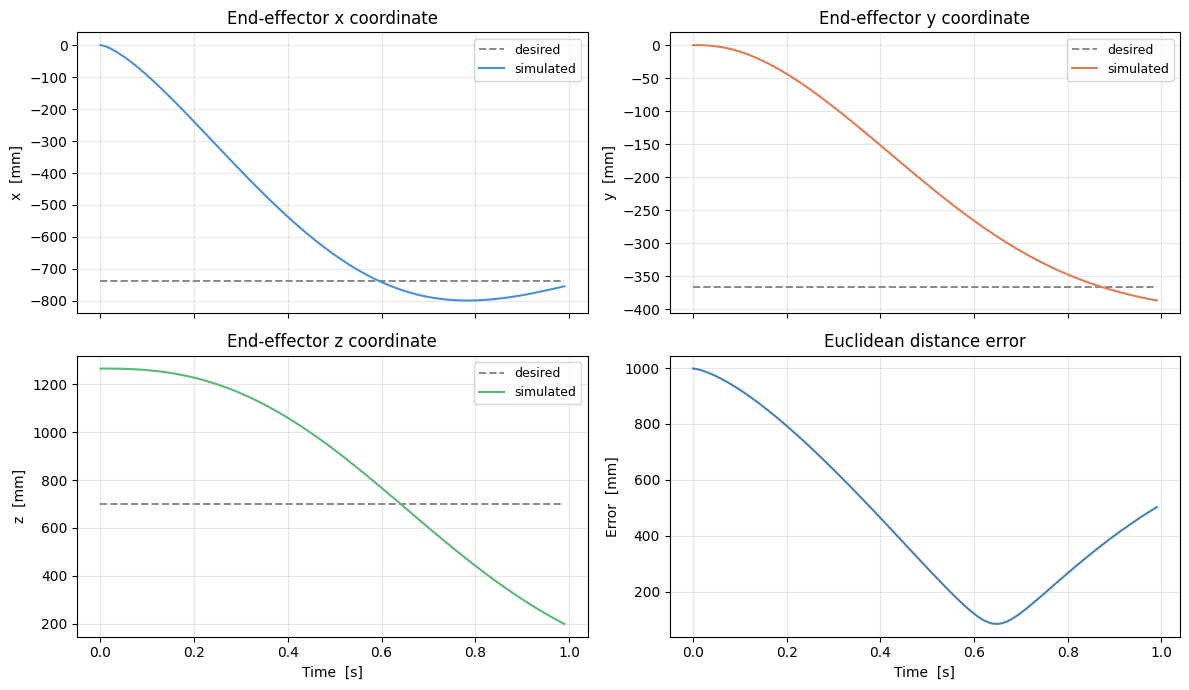

In [ ]:
desired_state_func = lambda t: [0.3, 1, 0.5, -0.3, 1, 0.5, 0.1]  # Example desired joint configuration

t, q, q_dot = simulate(test_PID, desired_state_func, q_0=np.zeros(7), q_dot_0=np.zeros(7), t_span=(0, 1))

plot_tracking_error(t, q, desired_state_func)

animate_robot(t, q)


### Instructions to group members for following questions

To run the tests in the other projects, you need to make two functions.
- desired_state_func(t) is a function that takes in t, the time, and then it returns the desired state q for that time. 
- tau_func(t, q, q_dot, desired_state_func) takes in the time, state (q and q_dot) and the desired state. Then it returns the tau vector, which is how much torque we want to apply to each joint. This is where you will implement a PID controller or whatever other controller you want to use.

Once you have defined these two, you can run the model with these functions simply by calling:

t, q, q_dot = simulate(tau_func, desired_state_func, q_0=np.zeros(7), q_dot_0=np.zeros(7), t_span=(0, 1))

As you can see, we pass the two functions you just made in as arguments in the simulation. q_0 and q_dot0 is the initial position and angular velocity of the joints, in the example above they are set so that all joint angles start at 0. t_span decides how long the simulation will run, in the example above it simulates one second. Setting this higher will make the program take longer to run (unfortunately it takes quite a while to run).

After you have called the simulation function above, you can plot the error between the actual end effector position and desired end effector position using the function:

plot_tracking_error(t, q, desired_state_func)

Or you can get a 3d plot of the robot moving by calling:

animate_robot(t, q)


# Question 3
Start implementing question 3 here etc. etc.